# Hybrid ALNS Performance Evaluation

## Section 1 - Introduction

Bin packing is a combinatorial optimization problem. We are given a list of item weights and identical bins with a fixed capacity. Every item must be assigned to exactly one bin, the total weight in each bin must not exceed the capacity, and the objective is to minimize the number of bins used.

This problem is difficult because a good packing depends on many interacting assignment decisions. A placement that looks good for one item can block better placements later. For realistic instance sizes, exact methods can become expensive, so heuristic and metaheuristic solvers are commonly used.

The solver evaluated here is a hybrid **Adaptive Large Neighborhood Search** solver, abbreviated **ALNS**. It starts from a feasible packing, repeatedly destroys part of the current solution, repairs the removed items, and keeps track of the best packing found.

The word **large** matters. A small local search move might move one item or swap two items. ALNS removes a group of items and rebuilds that part of the solution, so one iteration can change many assignments at once. This lets the solver escape local patterns that are hard to fix with single-item moves.

The solver uses three destroy operators:

- **Random destroy** removes a random set of items.
- **Worst-bin destroy** removes items from poorly filled bins.
- **Related-items destroy** removes items with similar sizes, giving repair a chance to reorganize a structured part of the packing.

After destruction, the solver repairs the partial solution. With learning disabled, repair uses a deterministic best-fit rule. With learning enabled, an offline Gradient Boosted Trees model scores feasible bin placements and selects the highest-scoring placement for each displaced item.

Candidate solutions are accepted with simulated annealing. If a candidate improves or preserves the bin count, it is accepted. If it is worse, it can still be accepted with probability `exp(-delta / temperature)`, where `delta` is the increase in bin count. The temperature cools over time, so the search is more exploratory early and more selective later.

The hybrid architecture has two learning components:

- **Offline GBT repair model**: trained before the benchmark and used to guide repair decisions.
- **Online LinUCB bandit**: updated during the ALNS run and used to choose the destroy operator from the current search context.

This notebook isolates the contribution of each learning component (the offline repair model and the online bandit) through an ablation study on a fixed benchmark slice.

---

## Utilities Used in This Notebook

The notebook uses three project utilities instead of reimplementing benchmarking logic inside notebook cells.

**Benchmarking utility**

The benchmarking utility creates a benchmark from a dataset key and a solver module. It loads matching instances, runs the solver, records one result row per instance, and saves the result table as CSV. Each row includes the instance name, dataset key, item count, bin capacity, bins used, lower bound, total weight, elapsed time, method label, and timeout status.

**Statistics utility**

The statistics utility loads benchmark CSV files and computes summary metrics. The main quality metric is `gap = bins_used - lower_bound`. Lower gap is better. The lower bound comes from known benchmark metadata when available; otherwise it is the continuous weight bound `ceil(total_weight / bin_capacity)`. The utility also reports average bins used, solve time, completion count, and fill rate. Fill rate is `total_weight / (bins_used * bin_capacity)`, so higher fill rate usually means less wasted capacity.

**Graphing utility**

The graphing utility reads benchmark CSV files and creates standard figures. Per-dataset graphs show solve time, bins versus lower bound, fill rate, and gap versus time. Comparison graphs show solve time and average bins by method. Cross-dataset graphs show solve time distribution, average gap, and size-versus-time trends.

The utilities keep the notebook cells short and make the experiments reproducible.

This cell imports the solver and the three utilities. It also hides non-essential warnings caused by loading a model artifact saved with an older scikit-learn version.

In [1]:
import warnings

from bin_packing_optimization.hybrid_learning_metaheuristics.hybrid_alns import (
    hybrid_alns_solver,
)
from bin_packing_optimization.hybrid_learning_metaheuristics.hybrid_alns.models import (
    load_repair_model,
)
from bin_packing_optimization.utilities.benchmarking import create_benchmark
import bin_packing_optimization.utilities.graphing as graphing
import bin_packing_optimization.utilities.statistics as statistics

warnings.filterwarnings("ignore", message="method=.*is ignored")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

---

## Section 2 - Ablation Study

The ablation uses **Scholl-2**, restricted to the smallest size class: 50 items and bin capacity 1000. Scholl instances are uniformly distributed benchmark instances with item counts from 50 to 500. Scholl-2 fixes the bin capacity at 1000.

The benchmark is limited to the first five sorted 50-item instances. This keeps the experiment short while still showing quality differences between learning configurations.

All four ablation runs use the same ALNS settings: 300 iterations, initial temperature `1 / log(2) = 1.4426950408889634`, and cooling rate `0.9995`. Only the two learning switches change.

### Configuration 1 - No Learning

This disables both learning components. Destroy operators are selected randomly and repair uses best-fit. This is the baseline.

In [2]:
benchmark = create_benchmark("scholl-2", hybrid_alns_solver, time_limit=3.0)

benchmark.run(
    method="no-learning",
    method_args={
        "max_iterations": 300,
        "initial_temperature": 1.4426950408889634,
        "alpha_cool": 0.9995,
        "use_offline_model": False,
        "use_online_rl": False,
    },
    max_instances=5,
)

no_learning_csv = benchmark.save_results_to_csv(
    "results/performance_evaluation/ablation/no-learning.csv"
)


Starting Benchmark: Scholl / Scholl 2
─────────────────────────────────────────────────────────────────────────────────────────
Instance │ Items │ Capacity │ LB │ Bins │ Gap │ Time (s)   │ Method               │ State
─────────────────────────────────────────────────────────────────────────────────────────


N1W1B1R0 │ 50    │ 1000     │ 18 │ 18   │ 0   │ 0.1176     │ no-learning          │ Done 


N1W1B1R1 │ 50    │ 1000     │ 18 │ 19   │ 1   │ 0.1658     │ no-learning          │ Done 


N1W1B1R2 │ 50    │ 1000     │ 19 │ 19   │ 0   │ 0.1177     │ no-learning          │ Done 


N1W1B1R3 │ 50    │ 1000     │ 18 │ 18   │ 0   │ 0.1712     │ no-learning          │ Done 


N1W1B1R4 │ 50    │ 1000     │ 17 │ 17   │ 0   │ 0.1877     │ no-learning          │ Done 
─────────────────────────────────────────────────────────────────────────────────────────



### Configuration 2 - Online Only

This keeps best-fit repair but enables the online LinUCB bandit for destroy-operator selection. The expected benefit is better destroy-operator choice than random selection.

In [3]:
benchmark = create_benchmark("scholl-2", hybrid_alns_solver, time_limit=3.0)

benchmark.run(
    method="online-only",
    method_args={
        "max_iterations": 300,
        "initial_temperature": 1.4426950408889634,
        "alpha_cool": 0.9995,
        "use_offline_model": False,
        "use_online_rl": True,
    },
    max_instances=5,
)

online_only_csv = benchmark.save_results_to_csv(
    "results/performance_evaluation/ablation/online-only.csv"
)


Starting Benchmark: Scholl / Scholl 2
─────────────────────────────────────────────────────────────────────────────────────────
Instance │ Items │ Capacity │ LB │ Bins │ Gap │ Time (s)   │ Method               │ State
─────────────────────────────────────────────────────────────────────────────────────────


N1W1B1R0 │ 50    │ 1000     │ 18 │ 18   │ 0   │ 0.1791     │ online-only          │ Done 


N1W1B1R1 │ 50    │ 1000     │ 18 │ 18   │ 0   │ 0.1744     │ online-only          │ Done 


N1W1B1R2 │ 50    │ 1000     │ 19 │ 19   │ 0   │ 0.1957     │ online-only          │ Done 


N1W1B1R3 │ 50    │ 1000     │ 18 │ 18   │ 0   │ 0.1939     │ online-only          │ Done 


N1W1B1R4 │ 50    │ 1000     │ 17 │ 17   │ 0   │ 0.1613     │ online-only          │ Done 
─────────────────────────────────────────────────────────────────────────────────────────



### Configuration 3 - Offline Only

This enables the GBT repair model but keeps random destroy-operator selection. The expected benefit is better repair placement decisions, with additional runtime from model scoring.

In [4]:
benchmark = create_benchmark("scholl-2", hybrid_alns_solver, time_limit=3.0)

benchmark.run(
    method="offline-only",
    method_args={
        "max_iterations": 300,
        "initial_temperature": 1.4426950408889634,
        "alpha_cool": 0.9995,
        "use_offline_model": True,
        "use_online_rl": False,
        "model_bundle": load_repair_model("repair_model_v2.pkl"),
    },
    max_instances=5,
)

offline_only_csv = benchmark.save_results_to_csv(
    "results/performance_evaluation/ablation/offline-only.csv"
)


Starting Benchmark: Scholl / Scholl 2
─────────────────────────────────────────────────────────────────────────────────────────
Instance │ Items │ Capacity │ LB │ Bins │ Gap │ Time (s)   │ Method               │ State
─────────────────────────────────────────────────────────────────────────────────────────


N1W1B1R0 │ 50    │ 1000     │ 18 │ 18   │ 0   │ 0.2509     │ offline-only         │ Done 


N1W1B1R1 │ 50    │ 1000     │ 18 │ 19   │ 1   │ 0.3684     │ offline-only         │ Done 


N1W1B1R2 │ 50    │ 1000     │ 19 │ 19   │ 0   │ 0.3550     │ offline-only         │ Done 


N1W1B1R3 │ 50    │ 1000     │ 18 │ 18   │ 0   │ 0.3412     │ offline-only         │ Done 


N1W1B1R4 │ 50    │ 1000     │ 17 │ 17   │ 0   │ 0.3310     │ offline-only         │ Done 
─────────────────────────────────────────────────────────────────────────────────────────



### Configuration 4 - Both Combined

This enables both learning components. The LinUCB bandit chooses destroy operators online and the GBT model guides repair. This is expected to improve average bins and average gap compared with the no-learning baseline.

In [5]:
benchmark = create_benchmark("scholl-2", hybrid_alns_solver, time_limit=3.0)

benchmark.run(
    method="both-combined",
    method_args={
        "max_iterations": 300,
        "initial_temperature": 1.4426950408889634,
        "alpha_cool": 0.9995,
        "use_offline_model": True,
        "use_online_rl": True,
        "model_bundle": load_repair_model("repair_model_v2.pkl"),
    },
    max_instances=5,
)

both_combined_csv = benchmark.save_results_to_csv(
    "results/performance_evaluation/ablation/both-combined.csv"
)


Starting Benchmark: Scholl / Scholl 2
─────────────────────────────────────────────────────────────────────────────────────────
Instance │ Items │ Capacity │ LB │ Bins │ Gap │ Time (s)   │ Method               │ State
─────────────────────────────────────────────────────────────────────────────────────────


N1W1B1R0 │ 50    │ 1000     │ 18 │ 18   │ 0   │ 0.2889     │ both-combined        │ Done 


N1W1B1R1 │ 50    │ 1000     │ 18 │ 19   │ 1   │ 0.4323     │ both-combined        │ Done 


N1W1B1R2 │ 50    │ 1000     │ 19 │ 19   │ 0   │ 0.3983     │ both-combined        │ Done 


N1W1B1R3 │ 50    │ 1000     │ 18 │ 18   │ 0   │ 0.3625     │ both-combined        │ Done 


N1W1B1R4 │ 50    │ 1000     │ 17 │ 17   │ 0   │ 0.2626     │ both-combined        │ Done 
─────────────────────────────────────────────────────────────────────────────────────────



This cell prints a method comparison table. The important columns are average bins, average gap, average fill rate, and average time.

In [6]:
statistics.print_method_comparison_report(
    [no_learning_csv, online_only_csv, offline_only_csv, both_combined_csv]
)


══════════════════════════════════════════════════════════════════════════════════════════
                                    METHOD COMPARISON                                     
══════════════════════════════════════════════════════════════════════════════════════════
method             │   done/total │   avg_bins │    avg_gap │  avg_fill(%) │  avg_time(s)
──────────────────────────────────────────────────────────────────────────────────────
no-learning        │          5/5 │    18.2000 │     0.2000 │      92.7644 │       0.1520
online-only        │          5/5 │    18.0000 │     0.0000 │      93.7554 │       0.1809
offline-only       │          5/5 │    18.2000 │     0.2000 │      92.7644 │       0.3293
both-combined      │          5/5 │    18.2000 │     0.2000 │      92.7644 │       0.3489


{'no-learning': {'instances': 5,
  'completed': 5,
  'timeouts': 0,
  'total_time_s': 0.7601099996827543,
  'avg_time_completed_s': 0.15202199993655086,
  'median_time_completed_s': 0.16581459995359182,
  'min_time_completed_s': 0.11762070003896952,
  'max_time_completed_s': 0.18772429996170104,
  'avg_bins_completed': 18.2,
  'avg_gap_completed': 0.2,
  'median_gap_completed': 0,
  'min_gap_completed': 0,
  'max_gap_completed': 1,
  'avg_fill_rate_completed_pct': 92.76442036463708,
  'median_fill_rate_completed_pct': 93.58333333333333},
 'online-only': {'instances': 5,
  'completed': 5,
  'timeouts': 0,
  'total_time_s': 0.9043536002282053,
  'avg_time_completed_s': 0.18087072004564106,
  'median_time_completed_s': 0.17913149995729327,
  'min_time_completed_s': 0.16131290001794696,
  'max_time_completed_s': 0.1956619000993669,
  'avg_bins_completed': 18,
  'avg_gap_completed': 0,
  'median_gap_completed': 0,
  'min_gap_completed': 0,
  'max_gap_completed': 0,
  'avg_fill_rate_complete

This cell creates the ablation graphs: solve-time distribution by method and average bins by method.

Comparison — Solve time distribution by method


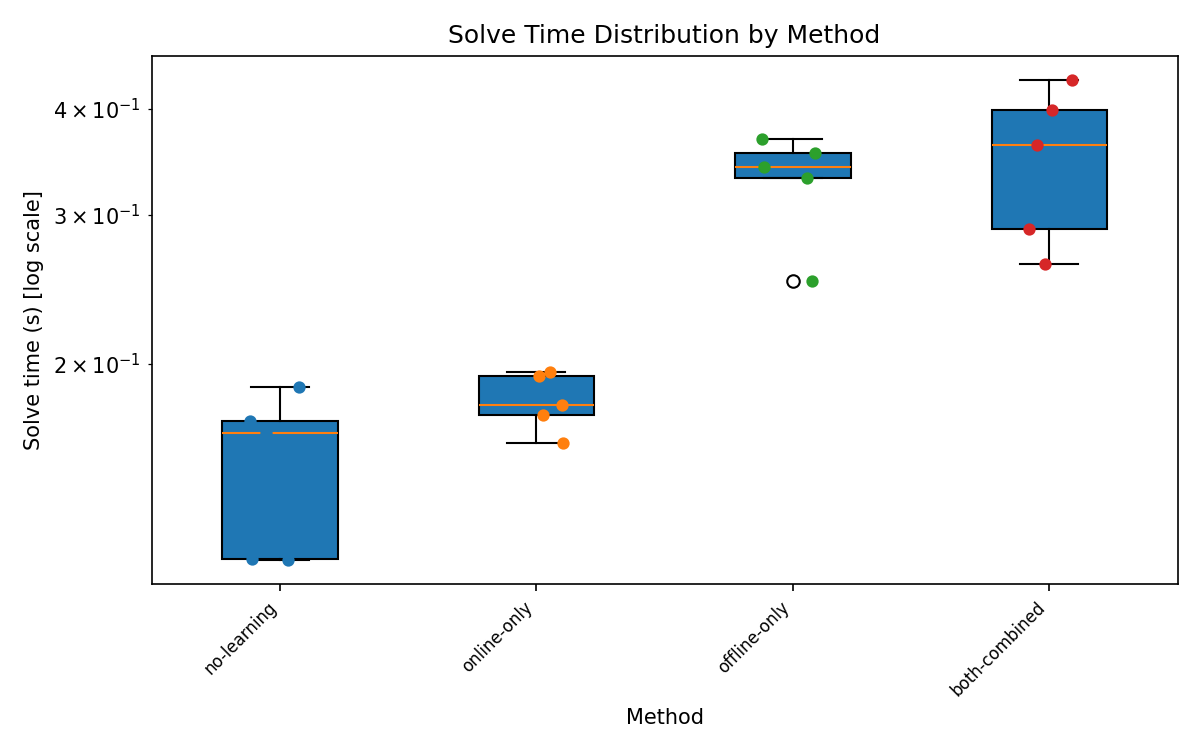


Comparison — Average bins used by method


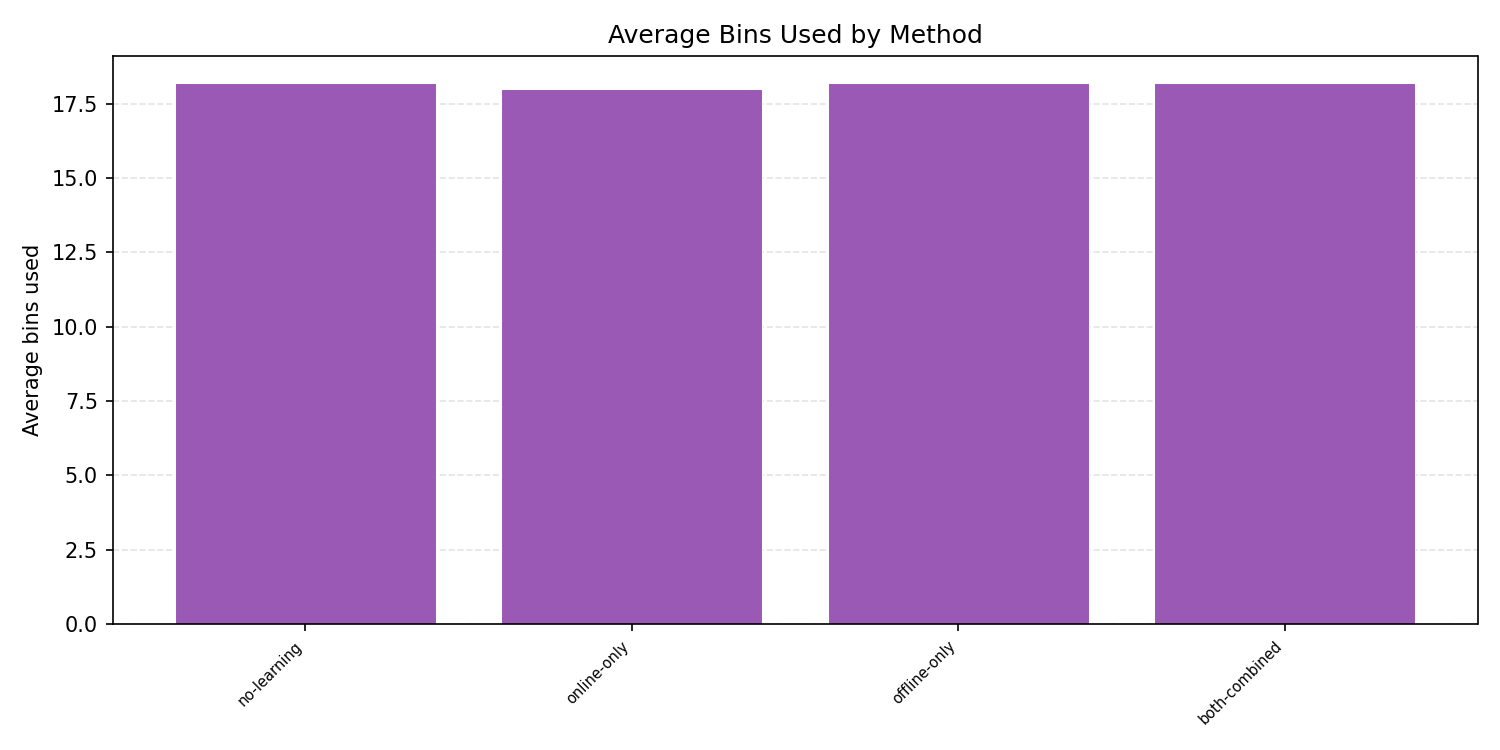

[WindowsPath('results/performance_evaluation/ablation/graphs/20260529_100826/compare_time_by_method.png'),
 WindowsPath('results/performance_evaluation/ablation/graphs/20260529_100826/compare_avg_bins_by_method.png')]

In [7]:
graphing.display_comparison_graphs(
    [no_learning_csv, online_only_csv, offline_only_csv, both_combined_csv],
    out_dir="results/performance_evaluation/ablation/graphs",
)

### Ablation Summary

The ablation isolates the solver components. The no-learning configuration gives the reference result. The online-only run tests whether adaptive destroy selection helps when repair is still greedy. The offline-only run tests whether learned repair helps when destroy selection is random. The combined run tests the full hybrid architecture.

The main quality comparison is no-learning versus both-combined. A lower average gap and lower average bins in the combined run indicates that the learning components improve solution quality on this benchmark slice. Runtime should be interpreted separately because learned repair performs model scoring during repair.